# Introduction to Computational Physics: Problem Set 1
Tutorial: Chun Ming Yip (Group 3)

Document created by: Vencel Szabó, Finn Zeumer

<hr>

# 0. Libaries

'Papulator' can be found under https://github.com/FinnZeumer/Papulator

By adding the _normal_ python file into the same folder as this protkect, the code will work rigth away.

In [195]:
# Libaries
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import pandas as pd
import time
 # Custom Libary from other project
import Papulator as pap
from Papulator import Sympy_Symbols as sym
from Papulator import const
from Papulator import Colors as col

<hr>

# 1. Data from Sheet

In [26]:
# Importing the Data form the exercise sheet

MM = np.array([0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10, 20, 40])

tau = np.array([56000, 10000, 3000, 1300, 400, 100, 20, 5, 3])

LL = np.array([0.05, 1.0, 5.0, 25, 80, 800, 10000, 100000, 500000])

RR = np.array([0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6, 10, 15])

temp = np.array([3800, 5800, 7200, 9000, 12000, 17000, 25000, 35000, 45000])

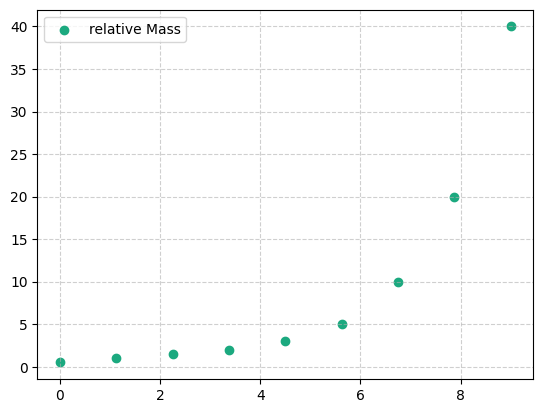

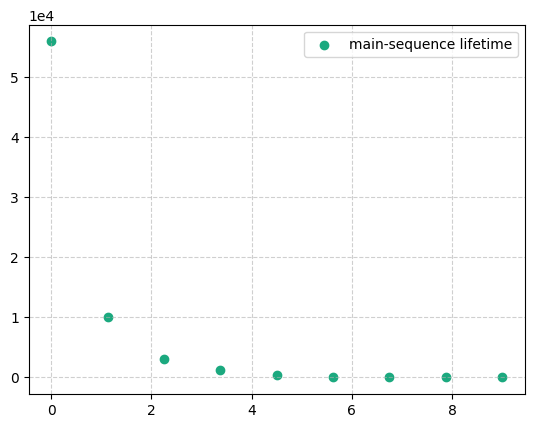

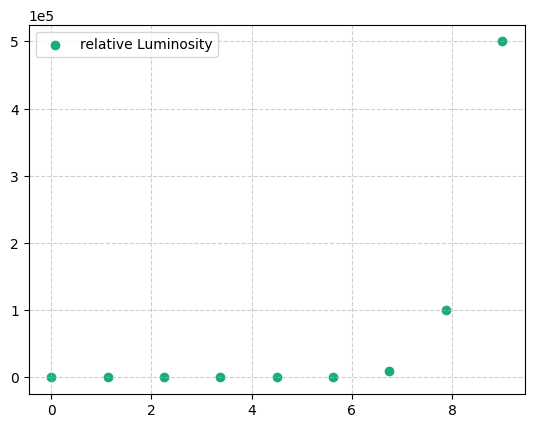

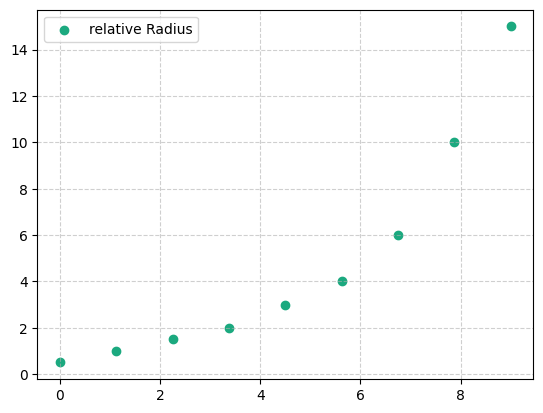

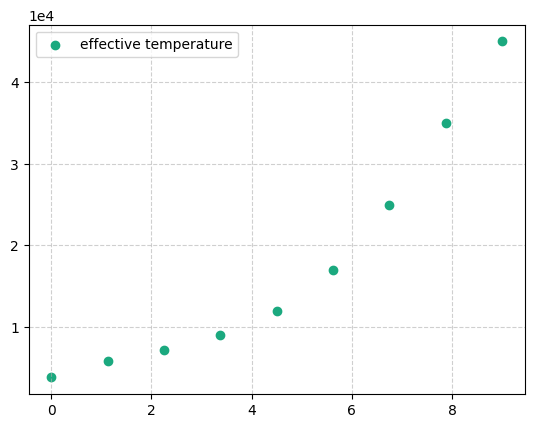

<Axes: >

In [27]:
# Plotting the data as scatter to get an vauge idea of the relation
x = np.linspace(0,9, 9)

plt.scatter(x, MM, label='relative Mass')
pap.plot_me()

plt.scatter(x, tau, label='main-sequence lifetime')
pap.plot_me()

plt.scatter(x, LL, label='relative Luminosity')
pap.plot_me()

plt.scatter(x, RR, label='relative Radius')
pap.plot_me()

plt.scatter(x, temp, label='effective temperature')
pap.plot_me()

# 2. Defining interpolation mehtods

In [28]:
# Test data
x_vals = np.array([0, 1, 2])
y_vals = np.array([0, 1, 0])

In [29]:
def linear_interpolation(x, y, x_approx):
    '''
    Method for linear interpolation

    params
    ------
    x: array-like
        the given x data points
    y: array-like
        the given y data points
    x_approx: array-like or float
        the x value(s) at which to approximate the y value(s)
    '''
    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length")

    # Find the interval index
    i = np.searchsorted(x, x_approx) - 1

    # Clamp index to valid range
    i = np.clip(i, 0, len(x) - 2)

    x0, x1 = x[i], x[i+1]
    y0, y1 = y[i], y[i+1]

    # Linear interpolation formula from the script
    return y0 + (y1 - y0) * (x_approx - x0) / (x1 - x0)

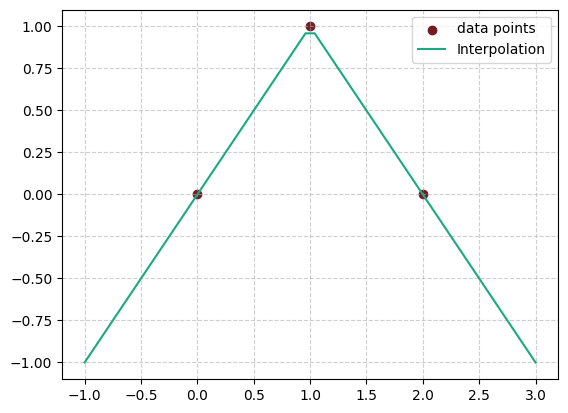

<Axes: >

In [30]:
x_test = np.linspace(-1, 3, 50)

linear_interpolation(x_vals, y_vals, x_test)

plt.scatter(x_vals, y_vals, label='data points', color=pap.Colors.WINE_RED)
plt.plot(x_test, linear_interpolation(x_vals, y_vals,x_test), label='Interpolation')
pap.plot_me()

In [31]:
def natural_cubic_spline(x, y):
    '''
    Create a natural cubic spline interpolation function.

    Parameters
    ----------
    x : array-like
        1D array of x values. Must be sorted in strictly increasing order.
    y : array-like
        1D array of y values. Must have the same length as x.

    Returns
    -------
    spline : function
        A function that takes new x values and returns interpolated y values.

    Notes/Idea
    -----
    - This implementation uses a natural Cubic Spline:
      the second derivative at the first and last point is =0
    - Internally, it solves a linear system to compute the second deriv. at each data point.
    - The interpolation is piecewise cubic between each pair of points.
    '''

    # Convert inputs to numpy arrays (in case they aren't already) and ensure they are floats
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    # At least 3 points are required for cubic spline interpolation
    if n < 3:
        raise ValueError("Need at least 3 points for cubic spline")

    # Compute distances between consecutive x values
    h = np.diff(x)

    # Matrix A (2D Array) and right-hand side vector for the linear system
    A = np.zeros((n, n))
    vec = np.zeros(n)

    # Natural boundary conditions: second derivative at the first and last point is zero
    A[0, 0] = 1
    A[-1, -1] = 1

    # Fill the system for interior points
    for i in range(1, n - 1):
        # left neighbor
        A[i, i-1] = h[i-1]
        # center
        A[i, i] = 2 * (h[i-1] + h[i])
        # right neighbor
        A[i, i+1] = h[i]

        # Difference of slopes between segments
        vec[i] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

    # Solve the system to get second derivatives at each point
    M = np.linalg.solve(A, vec)

    def spline(x_new):
        """
        Evaluate the spline at new x values.

        Parameters
        ----------
        x_new : float or array-like
            Points where the spline should be evaluated.

        Returns
        -------
        result : ndarray
            Interpolated values at x_new.
        """

        x_new = np.asarray(x_new)
        result = np.zeros_like(x_new, dtype=float)

        # Loop over each point
        for j, val in enumerate(x_new):

            # Find the interval the value belongs to
            # searchsorted returns the index where val should be inserted
            i = np.searchsorted(x, val) - 1

            # Clip index to valid range
            i = np.clip(i, 0, n - 2)

            # Get interval data
            hi = h[i]
            xi = x[i]
            xi1 = x[i+1]

            # Compute spline value using the cubic formula
            term1 = M[i] * (xi1 - val)**3 / (6 * hi)
            term2 = M[i+1] * (val - xi)**3 / (6 * hi)
            term3 = (y[i] - M[i] * hi**2 / 6) * (xi1 - val) / hi
            term4 = (y[i+1] - M[i+1] * hi**2 / 6) * (val - xi) / hi

            result[j] = term1 + term2 + term3 + term4

        return result

    return spline

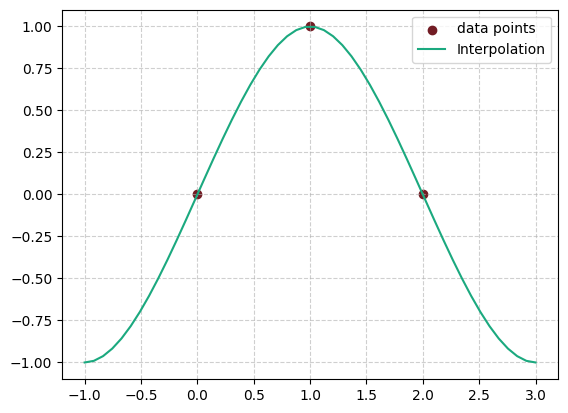

<Axes: >

In [32]:
# Simple example of the natural cubic spline interpolation
spline = natural_cubic_spline(x_vals, y_vals)

x_test = np.linspace(-1, 3, 50)
y_test = spline(x_test)

plt.scatter(x_vals, y_vals, label='data points', color=pap.Colors.WINE_RED)
plt.plot(x_test, y_test, label='Interpolation')
pap.plot_me()

In [33]:
# Getting the actual coefficients of the cubic spline for each interval
def compute_coefficients(x, y, M):
    n = len(x)
    h = np.diff(x)

    a = y[:-1]
    b = np.zeros(n-1)
    c = np.zeros(n-1)
    d = np.zeros(n-1)

    for i in range(n-1):
        b[i] = (y[i+1] - y[i]) / h[i] - h[i] * (2*M[i] + M[i+1]) / 6
        c[i] = M[i] / 2
        d[i] = (M[i+1] - M[i]) / (6*h[i])

    return a, b, c, d

In [34]:
# Build spline (reuse your code)
spline_func = natural_cubic_spline(x_vals, y_vals)

# Recompute M (copy from your function)
n = len(x_vals)
h = np.diff(x_vals)

A = np.zeros((n, n))
rhs = np.zeros(n)

A[0, 0] = 1
A[-1, -1] = 1

for i in range(1, n - 1):
    A[i, i-1] = h[i-1]
    A[i, i] = 2 * (h[i-1] + h[i])
    A[i, i+1] = h[i]
    rhs[i] = 6 * ((y_vals[i+1] - y_vals[i]) / h[i] - (y_vals[i] - y_vals[i-1]) / h[i-1])

M = np.linalg.solve(A, rhs)

# Compute coefficients
a, b, c, d = compute_coefficients(x_vals, y_vals, M)

print(f'The coefficients for the cubic spline are:\na: {a}\nb: {b}\nc: {c}\nd: {d}\n')

# Check at x_vals = 1
x_check = 1.0

# Left interval (i = 0)
i_left = 0
dx_left = x_check - x_vals[i_left]

S1_left = b[i_left] + 2*c[i_left]*dx_left + 3*d[i_left]*dx_left**2
S2_left = 2*c[i_left] + 6*d[i_left]*dx_left

# Right interval (i = 1)
i_right = 1
dx_right = x_check - x_vals[i_right]

S1_right = b[i_right] + 2*c[i_right]*dx_right + 3*d[i_right]*dx_right**2
S2_right = 2*c[i_right] + 6*d[i_right]*dx_right

print("First derivative left :", S1_left)
print("First derivative right:", S1_right)
print(f"is the same: {round(S1_left, 5) - round(S1_right, 5) == 0} \n")


print("Second derivative left :", S2_left)
print("Second derivative right:", S2_right)
print(f"is the same: {round(S2_left, 5) - round(S2_right, 5) == 0}")

The coefficients for the cubic spline are:
a: [0 1]
b: [1.5 0. ]
c: [ 0.  -1.5]
d: [-0.5  0.5]

First derivative left : 0.0
First derivative right: 0.0
is the same: True 

Second derivative left : -3.0
Second derivative right: -3.0
is the same: True


Since both derivertaives are the same we can assume that the curve ist actually smooth (at x = 1).

# 3. Interpolation in linear variables

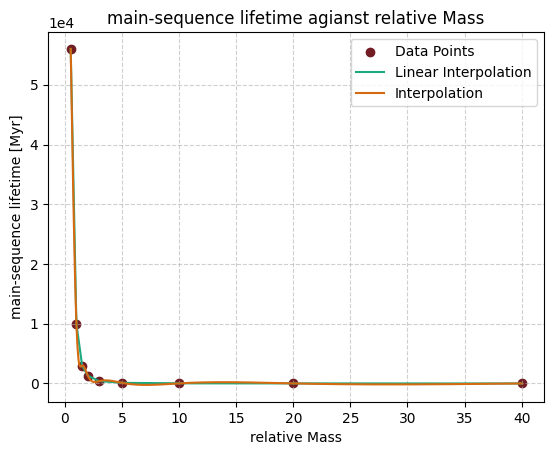

[]

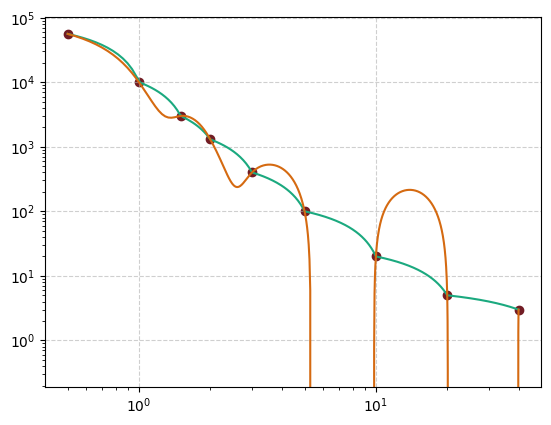

In [109]:
# Plotting the data with interpolation
reselution = np.linspace(MM[0], MM[-1], 1000)

# Plot 1: taug agianst M
# Data Points
plt.scatter(MM, tau, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(MM, tau, reselution),
         label='Linear Interpolation')

# Spline
spline_1 = natural_cubic_spline(MM, tau)

y_1 = spline_1(reselution)
plt.plot(reselution, y_1, label='Interpolation')

# Inspekting the wiggling:
# plt.xlim(0,5)

# Design
pap.plot_me('main-sequence lifetime agianst relative Mass', 'relative Mass', 'main-sequence lifetime [Myr]')

# Data Points
plt.scatter(MM, tau, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(MM, tau, reselution),
         label='Linear Interpolation')

# Spline
spline_1 = natural_cubic_spline(MM, tau)

y_1 = spline_1(reselution)
plt.plot(reselution, y_1, label='Interpolation')

plt.loglog()

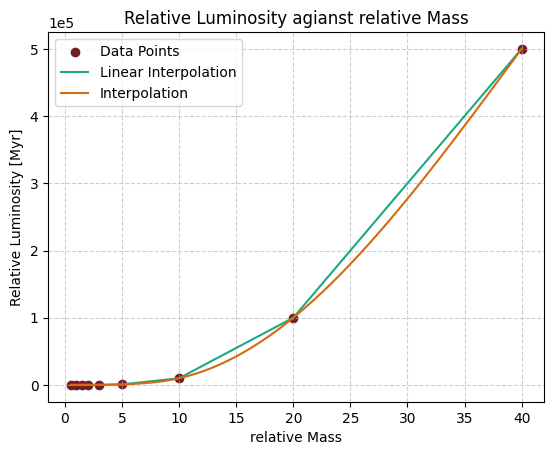

[]

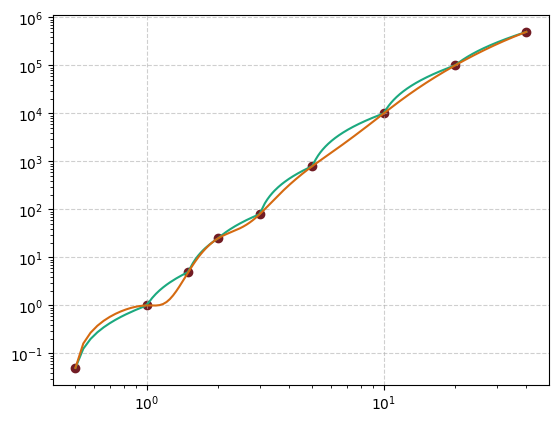

In [71]:
# Plot 2: L agianst M
# Data Points
plt.scatter(MM, LL, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(MM, LL, reselution),
         label='Linear Interpolation')

# Spline
spline_2 = natural_cubic_spline(MM, LL)

y_2 = spline_2(reselution)
plt.plot(reselution, y_2, label='Interpolation')

# Design
pap.plot_me('Relative Luminosity agianst relative Mass', 'relative Mass', 'Relative Luminosity [Myr]')

# Log log
# Data Points
plt.scatter(MM, LL, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(MM, LL, reselution),
         label='Linear Interpolation')

# Spline
spline_2 = natural_cubic_spline(MM, LL)

y_2 = spline_2(reselution)
plt.plot(reselution, y_2, label='Interpolation')

plt.loglog()

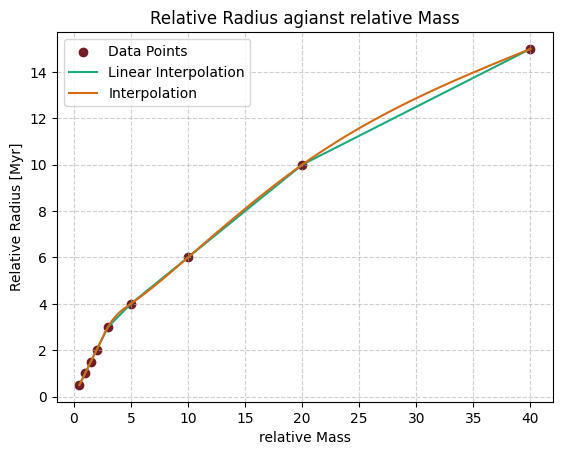

[]

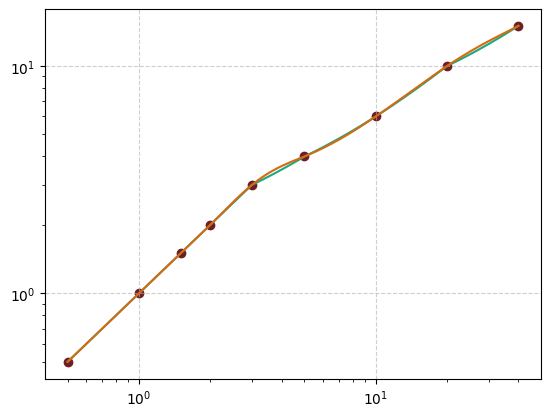

In [117]:
# Plot 3: R agianst M
# Data Points
plt.scatter(MM, RR, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(MM, RR, reselution),
         label='Linear Interpolation')

# Spline
spline_3 = natural_cubic_spline(MM, RR)

y_3 = spline_3(reselution)
plt.plot(reselution, y_3, label='Interpolation')

# Design
pap.plot_me('Relative Radius agianst relative Mass', 'relative Mass', 'Relative Radius [Myr]')

# log Log
# Data Points
plt.scatter(MM, RR, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(MM, RR, reselution),
         label='Linear Interpolation')

# Spline
spline_3 = natural_cubic_spline(MM, RR)

y_3 = spline_3(reselution)
plt.plot(reselution, y_3, label='Interpolation')

plt.loglog()

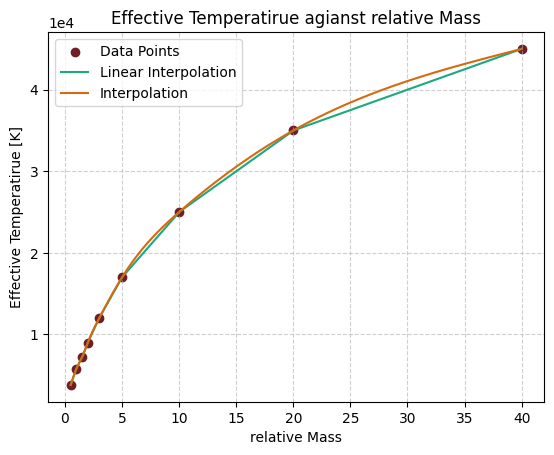

[]

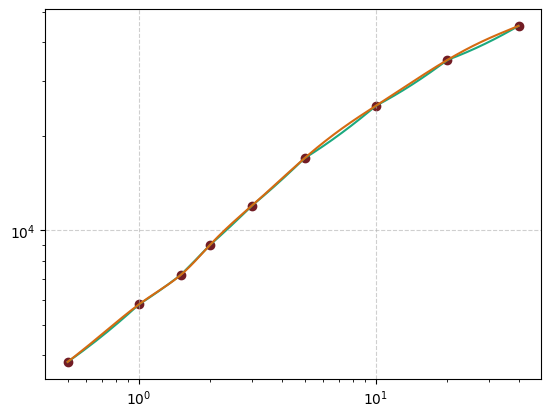

In [115]:
# Plot 4: temp agianst M
# Data Points
plt.scatter(MM, temp, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(MM, temp, reselution),
         label='Linear Interpolation')

# Spline
spline_4 = natural_cubic_spline(MM, temp)

y_4 = spline_4(reselution)
plt.plot(reselution, y_4, label='Interpolation')

# Design
pap.plot_me('Effective Temperatirue agianst relative Mass', 'relative Mass', 'Effective Temperatirue [K]')


# log Log
plt.scatter(MM, temp, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(MM, temp, reselution),
         label='Linear Interpolation')

# Spline
spline_4 = natural_cubic_spline(MM, temp)

y_4 = spline_4(reselution)
plt.plot(reselution, y_4, label='Interpolation')
plt.loglog()

## Discussion

In the linear space most graphs _look_ fine. 
But the linear interpolation will always underestimate the true values in the plot,
while the natural cubic spline does sometimes some wigglingding to both, under- and over-estimation. 
This phenomenon is well represented in the firts plot for the first couple of values. 

In the log-log space gain, mostly the plots _look_ fine, but we will find again a couple of things not correct here. 
Expecially, Plot 1 gets messed up quite badly. The wiggeling gets so out of hand that even negative values get represented – which for time units is now what we want. This is by far the worst interpolation of the four; this representation is not just unlikly, but also not plausable, especially for higher mass. 

The second plot shows similar behaviour, but not as badly. 
Here the linear interpolation is also quite interesting, since in the linear space lines are just lines, in log-log space the become exponentials. So it is not longer true that the values will always be underestimated, the can also overestimate the plot. 

For the last two plots the lineare and the cubic spline interpolation do look quite simular and identical. In the linear space they seem so estimate the values quite well, wile in the log space we would expecte something that looks more like a single line, but we see a couple of _"single lines"_ that got connected. So we have somesort of good estimation but know we could do better. 


<hr>

# 4. Interpolation in logarithmic variables

In [131]:
# calculating the log of data

log_MM = np.log10(MM)

log_tau = np.log10(tau)

log_LL = np.log10(LL)

log_RR = np.log10(RR)

log_temp = np.log10(temp)

(0.12589254117941673, np.float64(2.2458875776497824))

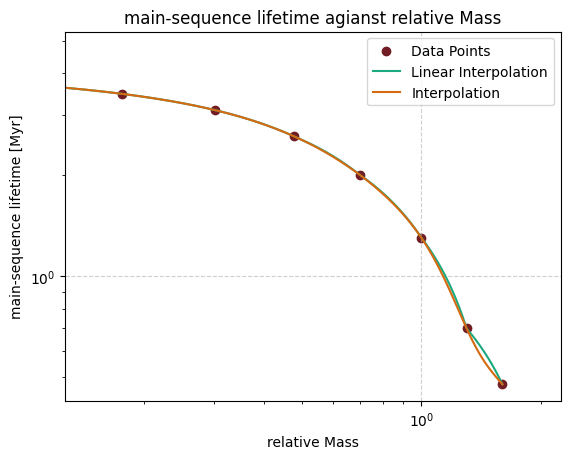

In [164]:
# Plotting the data with interpolation
reselution = np.linspace(log_MM[0], log_MM[-1], 1000)

# Plot 1: taug agianst M
# Data Points
plt.scatter(log_MM, log_tau, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(log_MM, log_tau, reselution),
         label='Linear Interpolation')

# Spline
spline_1 = natural_cubic_spline(log_MM, log_tau)

y_1 = spline_1(reselution)
plt.plot(reselution, y_1, label='Interpolation')

plt.loglog()
plt.legend()
plt.title('main-sequence lifetime agianst relative Mass')
plt.xlabel('relative Mass')
plt.ylabel('main-sequence lifetime [Myr]')
plt.xlim(10**-0.9)

(0.3981071705534972, np.float64(7.984266797092925))

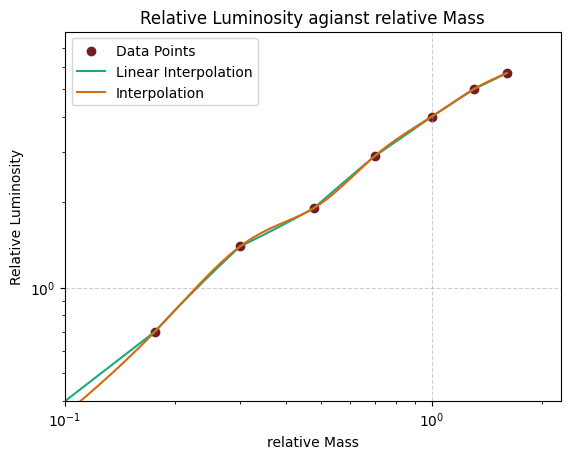

In [170]:
# Plot 2: L agianst M
# Data Points
plt.scatter(log_MM, log_LL, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(log_MM, log_LL, reselution),
         label='Linear Interpolation')

# Spline
spline_2 = natural_cubic_spline(log_MM, log_LL)

y_2 = spline_2(reselution)
plt.plot(reselution, y_2, label='Interpolation')

plt.loglog()
plt.legend()
plt.title('Relative Luminosity agianst relative Mass')
plt.xlabel('relative Mass')
plt.ylabel('Relative Luminosity')
plt.xlim(10**-1)
plt.ylim(10**-0.4)

(0.12589254117941673, np.float64(1.6234479637878225))

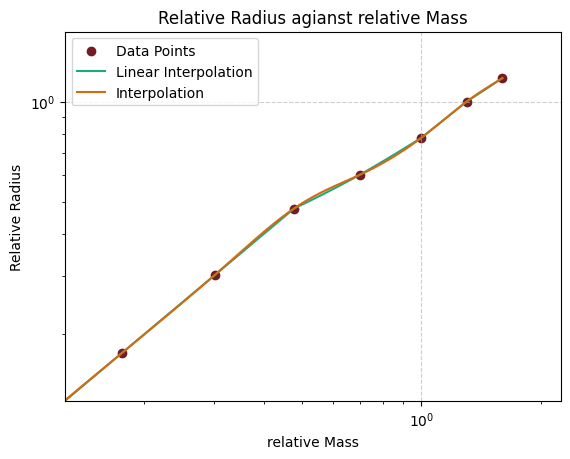

In [140]:
# Plot 3: R agianst M
# Data Points
plt.scatter(log_MM, log_RR, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(log_MM, log_RR, reselution),
         label='Linear Interpolation')

# Spline
spline_3 = natural_cubic_spline(log_MM, log_RR)

y_3 = spline_3(reselution)
plt.plot(reselution, y_3, label='Interpolation')

plt.loglog()
plt.legend()
plt.title('Relative Radius agianst relative Mass')
plt.xlabel('relative Mass')
plt.ylabel('Relative Radius')
plt.xlim(10**-0.9)
plt.ylim(10**-0.9)

(0.1, np.float64(2.2458875776497824))

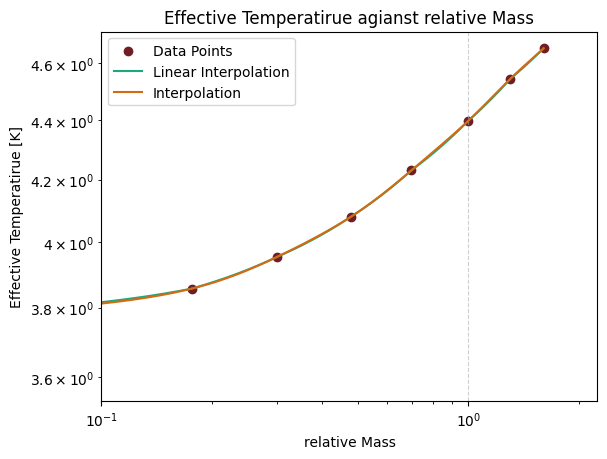

In [161]:
# Plot 4: log_temp agianst M
plt.scatter(log_MM, log_temp, label='Data Points', color = pap.Colors.WINE_RED)

#linear Interpolation
plt.plot(reselution,
         linear_interpolation(log_MM, log_temp, reselution),
         label='Linear Interpolation')

# Spline
spline_4 = natural_cubic_spline(log_MM, log_temp)

y_4 = spline_4(reselution)
plt.plot(reselution, y_4, label='Interpolation')
plt.loglog()
plt.legend()
plt.title('Effective Temperatirue agianst relative Mass')
plt.xlabel('relative Mass')
plt.ylabel('Effective Temperatirue [K]')
plt.xlim(10**-1)

In [171]:
# Claculation back to physical properties

# Phsyical property = 10^{y_log}
phy_tau = 10**(y_1)
phy_LL = 10**(y_2)
phy_RR = 10**(y_3)
phy_temp = 10**(y_4)

print(phy_tau[0], phy_tau[-1])
# Those values are the same as in the table (first and last entrie) 

56000.00000000004 3.0


## Comparison to linear variables

The comparison clearly shows a much better representation of the log variables. There is no extrem wiggeling anymore. The curves now seem more resonable in a physical sense, but still not perfect. Especially, the second and third graph have still the "_single connected lines_", althogh we expect just a signle line.

## Why Log-Log Interpolation --> Piecewise Power-Law

**1. Mathamatically:**
Interpolating linearly in log-space fits a straight line:
$$ \log_{10} Q = m \cdot \log_{10} M + c $$

**2. Transform Back to Physical Units:**
Exponentiate both sides (base 10):
$$ Q = 10^{(m \cdot \log_{10} M + c)} $$
$$ Q = 10^c \cdot (10^{\log_{10} M})^m $$
$$ Q = A \cdot M^m $$
*(Where $A = 10^c$ is a constant and $m$ is the slope)*

**3. Conclusion**
The equation $Q = A \cdot M^m$ is the definition of a **power law**.
* **Linear interpolation in log-space** $\rightarrow$ **Power-law curve in physical space**.
* Doing this between every pair of data points creates a **piecewise power-law** function.

**Why it works for stars:**
Stellar quantities ($L, R, \tau$) naturally follow power laws ($Q \propto M^k$). Log-log interpolation enforces this physical scaling exactly between data points, unlike linear interpolation which assumes a constant rate of change ($Q \propto M$).

# 5. Lifetime from luminosity

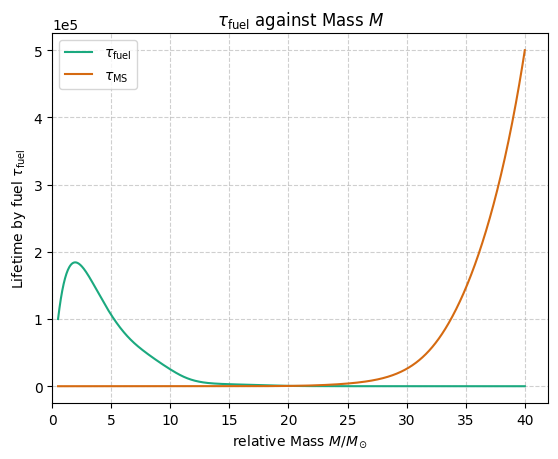

<Axes: title={'center': '$\\tau_\\text{fuel}$ against Mass $M$'}, xlabel='relative Mass $M/M_\\odot$', ylabel='Lifetime by fuel $\\tau_\\text{fuel}$'>

In [210]:
lin_reselution = np.linspace(MM[0], MM[-1], 1000)

tau_fuel  = 10**4 * (lin_reselution)/(phy_LL)

plt.plot(lin_reselution, tau_fuel, label=r"$\tau_\text{fuel}$")
plt.plot(lin_reselution, phy_LL, label=r"$\tau_\text{MS}$")

#negative Values do not make any sense (physically impossible)
plt.xlim(0)

pap.plot_me(r'$\tau_\text{fuel}$ against Mass $M$',
            r'relative Mass $M/M_\odot$',
            r'Lifetime by fuel $\tau_\text{fuel}$')

# DOES NOT WORK INVESTIGATE

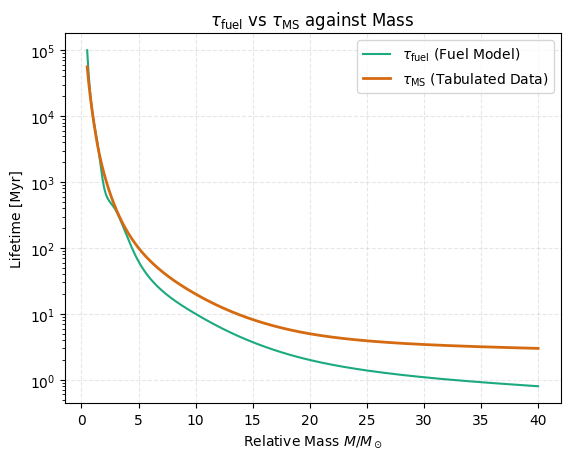

In [224]:
# Start from scratch to get plot

log_M_space = np.linspace(np.log10(MM[0]), np.log10(MM[-1]), 1000)

spline_tau = natural_cubic_spline(log_MM, log_tau)
spline_L = natural_cubic_spline(log_MM, log_LL)

log_tau_interp = spline_tau(log_M_space) 
log_L_interp   = spline_L(log_M_space)   

# Make it linear
phy_M = 10**log_M_space          
phy_tau_tab = 10**log_tau_interp 
phy_L = 10**log_L_interp

tau_fuel = 10**4 * (phy_M / phy_L)

# 5. Plotting
plt.figure()
plt.plot(phy_M, tau_fuel, label=r"$\tau_\text{fuel}$ (Fuel Model)")
plt.plot(phy_M, phy_tau_tab, label=r"$\tau_\text{MS}$ (Tabulated Data)", linewidth=2)

plt.xlabel(r'Relative Mass $M/M_\odot$')
plt.ylabel(r'Lifetime [Myr]')
plt.title(r'$\tau_\text{fuel}$ vs $\tau_\text{MS}$ against Mass')
plt.legend()
plt.grid(True, alpha=0.3)

# plt.loglog()
plt.yscale('log') 

plt.show()

## Comparison
The two curves to look simular, especially for a relative Mass of $\approx 5$, but then start to diverge. The fuel Model also has some wiggeling. Still, for small masses both methods are good approximations. 

The scaling $\tau \sim M/L$ works well because it correctly identifies that lifetime is determined by the ratio of available nuclear fuel to the rate of consumption. However, it is imperfect because:
+ Fuel Availability: The fraction of stellar mass available for fusion decreases for high-mass stars compared to low-mass stars.

+ Fusion Mechanisms: The transition from mass to Luminosity does not scale linear.

+ Structural Changes: Variations cause the exponent in the $L \sim M^\alpha$ relation to vary, meaning a single normalization factor ($10^4$ Myr) cannot fit the entire mass range perfectly.